# Gridworld MDP

Designed an MDP for a drone tasked with navigating a windy forest that has caught fire. The
drone must pick up water from the lake and deliver it to the active fire zone while avoiding
smoke fumes (that hinder movement and poison the water) and crashing into boulders.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches



## Special States

In [38]:
lake=(0,0)              #Drone picks up water
fire=[(4,4)]            #Drone drops water on fire
smoke=[(1,2),(3,2)]     #Hazardous smoke regions
boulders=[(3,4),(2,4)]  #Drone crashes into boulders


## Some Util Functions

In [39]:
def terminal(state):  # To check if a state is terminal or not
    if tuple(state[1:3]) in fire and state[0]:
        return True
    elif tuple(state[1:3]) in boulders:
        return True 
    else:
        return False
    
def reward(state, smoke_penalty=-10):       #Reward function for the gridworld
    pos = tuple(state[1:3])
    rew=-1
    if pos in fire and state[0]:            # Going to fire without water is pointless
        return 100
    elif pos in smoke:                      # Additional penalty for flying into hazardous regions
        rew+=smoke_penalty
    elif pos in boulders:                   # Worst case scenario, drone crashes
        return -100
    return rew

def movement(state, dirc):                  # New state, given a state and an action
    if state[1]==0 and state[2]==0:
        state=(1,0,0)
    if dirc=='N':
        if tuple(state[1:3])==(0,1) and not state[0]:
            return (1, 0,0)
        return state if state[2] == 0 else (state[0], state[1], state[2]-1)
    
    elif dirc=='S':
        return state if state[2] == 4 else (state[0], state[1], state[2]+1)
    
    elif dirc=='E':
        return state if state[1] == 4 else (state[0], state[1]+1, state[2])
    
    elif dirc=='W':
        if tuple(state[1:3])==(1,0) and not state[0]:
            return (1, 0,0)
        return state if state[1] == 0 else (state[0], state[1]-1, state[2])
    
    else:
        return state
    
def possible_states(state,dirc):        # Possible states, given a state and an action
    if dirc == 'N':
        return [movement(state, 'N'), movement(state, 'E'), movement(state, 'W'),movement(state, 'H')]
    elif dirc == 'S':
        return [movement(state, 'S'), movement(state, 'E'), movement(state, 'W'),movement(state, 'H')]
    elif dirc == 'E':
        return [movement(state, 'E'), movement(state, 'N'), movement(state, 'S'),movement(state, 'H')]
    elif dirc == 'W':
        return [movement(state, 'W'), movement(state, 'N'), movement(state, 'S'),movement(state, 'H')]

def get_optimal_action(state, gamma, gridWorld, smoke_penalty=-10):  #Getting optimal action of the optimal policy (For visualisation purpose)

    best_action = 'H'
    best_value = -float('inf')
    
    directions = ['N', 'S', 'E', 'W', 'H']  
    
    for dirc in directions:
        temp_val = 0
        
        if dirc == 'H':
            temp_val = reward(state, smoke_penalty) + gamma * gridWorld[state[0], state[1], state[2]]
        else:
            p_states = possible_states(state, dirc)
            
            if tuple(state[1:3]) in smoke:
                temp_val += 0.4 * (reward(p_states[0], smoke_penalty) + gamma * gridWorld[p_states[0][0], p_states[0][1], p_states[0][2]])
                temp_val += 0.4 * (reward(p_states[3], smoke_penalty) + gamma * gridWorld[p_states[3][0], p_states[3][1], p_states[3][2]])
                for i in range(1, 3):
                    p_state = p_states[i]
                    temp_val += 0.1 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])

            else:
                temp_val += 0.7 * (reward(p_states[0], smoke_penalty) + gamma * gridWorld[p_states[0][0], p_states[0][1], p_states[0][2]])
                for i in range(1, 4):
                    p_state = p_states[i]
                    temp_val += 0.1 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
        
        if temp_val > best_value:
            best_value = temp_val
            best_action = dirc
    
    return best_action


## Value function

The optimal value function is computed using the Bellman optimality equation:
$$V^*(s) = \max_{a \in \{N, S, E, W, H\}} \sum_{s'} P(s'|s, a) [r+ \gamma \cdot V^*(s')]$$




In [40]:
def value_func( state, gamma, gridWorld, smoke_penalty=-10):
    
    hover_val = reward(state, smoke_penalty) + gamma * gridWorld[state[0], state[1], state[2]]  #Hovering in place
    value =  hover_val
    
    if tuple(state[1:3]) in smoke:      # Transition probabilities change
        for dirc in ['N','S','E','W']:     
            temp_val=0
            p_states = possible_states(state, dirc)
            p_state = p_states[0]
            temp_val += 0.4 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            
            p_state = p_states[3]
            temp_val += 0.4 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            
            for i in range(1,3):
                p_state = p_states[i]
                temp_val += 0.1 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            value = max(value, temp_val)
                    
    else:
        for dirc in ['N','S','E','W']:
            temp_val=0
            p_states = possible_states(state, dirc)

            p_state = p_states[0]
            temp_val += 0.7 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            
            for i in range(1,4):
                p_state = p_states[i]
                temp_val += 0.1 * (reward(p_state, smoke_penalty) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            value = max(value, temp_val)
        
    return value
        

## Policy Iteration

To evaluate the policy, we use the formula:
$$V_{k+1}(s) = \max_{a \in \{N, S, E, W, H\}} \sum_{s'} P(s'|s, a) [r+ \gamma \cdot V_k(s')]$$


In [41]:
def policy_iteration(gamma, theta,smoke_penalty=-10):
    gridWorld=np.zeros((2,5,5), dtype=float)
    delta = float('inf')
    
    while delta > theta:
        for i in range(1,-1,-1):
            for j in range(4,-1,-1):
                for k in range(4,-1,-1):
                    state = [i,j,k]
                    if not terminal(state):  # Only update non-terminal states
                        v = gridWorld[i,j,k]
                        gridWorld[i,j,k] = value_func(state, gamma, gridWorld, smoke_penalty)
                        delta = min(delta, abs(v - gridWorld[i,j,k]))

    return gridWorld
                    


## Visualisating the MDP for better insight

In [42]:
def visualize_mdp(gridWorld, gamma=0.95,smoke_penalty=-10):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors = {
        'lake': '#87CEEB',      # Sky blue
        'fire': '#FF4500',      # Orange red
        'smoke': '#708090',     # Slate gray
        'boulder': '#2F4F4F',   # Dark slate gray
        'normal': '#F5F5DC'     # Beige
    }
    
    for phase in range(2):
        ax = axes[phase]
        
        color_grid = np.full((5, 5, 3), [0.96, 0.96, 0.86])  # Default beige color
        color_grid[0, 0] = [0.53, 0.81, 0.92]  # Sky blue
        color_grid[4, 4] = [1.0, 0.27, 0.0]  # Orange red
        color_grid[2, 1] = [0.44, 0.50, 0.56]  # Slate gray
        color_grid[2, 3] = [0.44, 0.50, 0.56]  # Slate gray
        color_grid[4, 3] = [0.18, 0.31, 0.31]  # Dark slate gray
        color_grid[4, 2] = [0.18, 0.31, 0.31]  # Dark slate gray
        
        ax.imshow(color_grid, extent=[0, 5, 0, 5], origin='lower', aspect='auto') # Displaying the grid
        
        for i in range(6):
            ax.axhline(i, color='black', linewidth=1.5)
            ax.axvline(i, color='black', linewidth=1.5)

        for boulder_x in [2, 3]:
            rect = mpatches.Rectangle((boulder_x, 4), 1, 1, 
                                     linewidth=0, edgecolor='white', 
                                     facecolor='none', hatch='////', fill=False)
            ax.add_patch(rect)
        
        if phase == 1:
            rect = mpatches.Rectangle((4, 4), 1, 1, 
                                     linewidth=0, edgecolor='white', 
                                     facecolor='none', hatch='////', fill=False)
            ax.add_patch(rect)
        
        
        for i in range(5): # Added value function text and policy arrows in each cell (skip terminal states)
            for j in range(5):                
                if not terminal([phase, i, j]):
                    value = gridWorld[phase, i, j]
                    ax.text(i + 0.5, j + 0.75, f'{value:.1f}', 
                           ha='center', va='center', fontsize=9, fontweight='bold')
                    
                    state = [phase, i, j]
                    optimal_action = get_optimal_action(state, gamma, gridWorld, smoke_penalty)
                    
                    arrow_length = 0.2
                    arrow_props = dict(arrowstyle='->', lw=2.5, color='darkblue')
                    
                    if optimal_action == 'H':
                        circle = plt.Circle((i + 0.5, j + 0.5), 0.15, color='red', fill=False, linewidth=2.5)
                        ax.add_patch(circle)
                    elif optimal_action == 'N':
                        ax.annotate('', xy=(i + 0.5, j + 0.5 - arrow_length), 
                                   xytext=(i + 0.5, j + 0.5 + arrow_length),
                                   arrowprops=arrow_props)
                    elif optimal_action == 'S':
                        ax.annotate('', xy=(i + 0.5, j + 0.5 + arrow_length), 
                                   xytext=(i + 0.5, j + 0.5 - arrow_length),
                                   arrowprops=arrow_props)
                    elif optimal_action == 'E':
                        ax.annotate('', xy=(i + 0.5 + arrow_length, j + 0.5), 
                                   xytext=(i + 0.5 - arrow_length, j + 0.5),
                                   arrowprops=arrow_props)
                    elif optimal_action == 'W':
                        ax.annotate('', xy=(i + 0.5 - arrow_length, j + 0.5), 
                                   xytext=(i + 0.5 + arrow_length, j + 0.5),
                                   arrowprops=arrow_props)

        ax.set_xlim(0, 5)
        ax.set_ylim(0, 5)
        ax.set_xticks(np.arange(0.5, 5.5, 1))
        ax.set_yticks(np.arange(0.5, 5.5, 1))
        ax.set_xticklabels(range(5))
        ax.set_yticklabels(range(5))
        ax.set_xlabel('X coordinate', fontsize=12)
        ax.set_ylabel('Y coordinate', fontsize=12)
        
        if phase == 0:
            ax.set_title('Phase 0: Before Picking Up Water', fontsize=14, fontweight='bold')
        else:
            ax.set_title('Phase 1: After Picking Up Water', fontsize=14, fontweight='bold')
        
        ax.grid(False)
    
    legend_elements = [
        mpatches.Patch(facecolor='#87CEEB', edgecolor='black', label='Lake (0,0)'),
        mpatches.Patch(facecolor='#FF4500', edgecolor='black', label='Fire (4,4) - Terminal in Phase 1'),
        mpatches.Patch(facecolor='#708090', edgecolor='black', label='Smoke (1,2), (3,2)'),
        mpatches.Patch(facecolor='#2F4F4F', edgecolor='black', label='Boulders (3,4), (2,4) - Terminal'),
        mpatches.Patch(facecolor='#F5F5DC', edgecolor='black', label='Normal cells'),
        mpatches.Patch(facecolor='none', edgecolor='red', label='Red Circle = Hover Action')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=6, 
              bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=True)
    
    fig.suptitle(f'Optimal Policy for Gamma={gamma})', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, top=0.88)
    plt.show()




## Testing the MDP

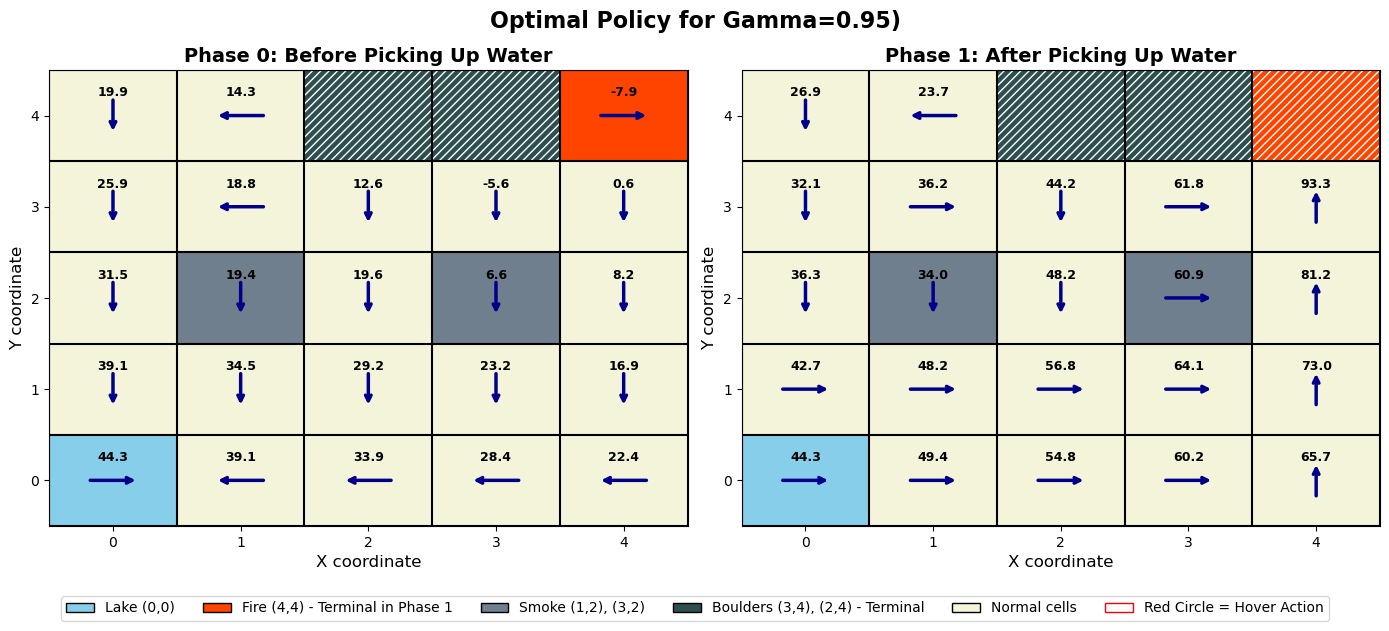

In [43]:
gridWorld=policy_iteration(0.95, 0.01)
visualize_mdp(gridWorld, gamma=0.95)

## Smaller Discount Rate 

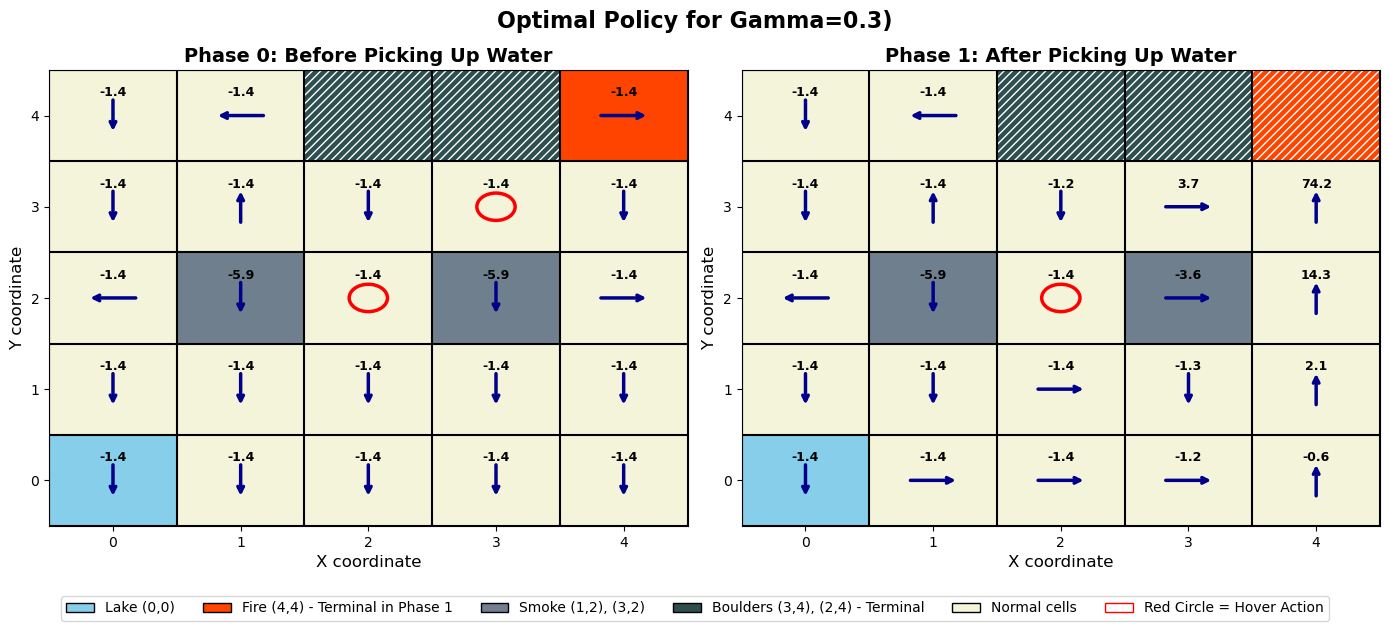

In [44]:
gridWorld_alt_Gamma=policy_iteration(0.3, 0.01)
visualize_mdp(gridWorld_alt_Gamma, gamma=0.3)

## Harsher Penalty on entering smoke regions

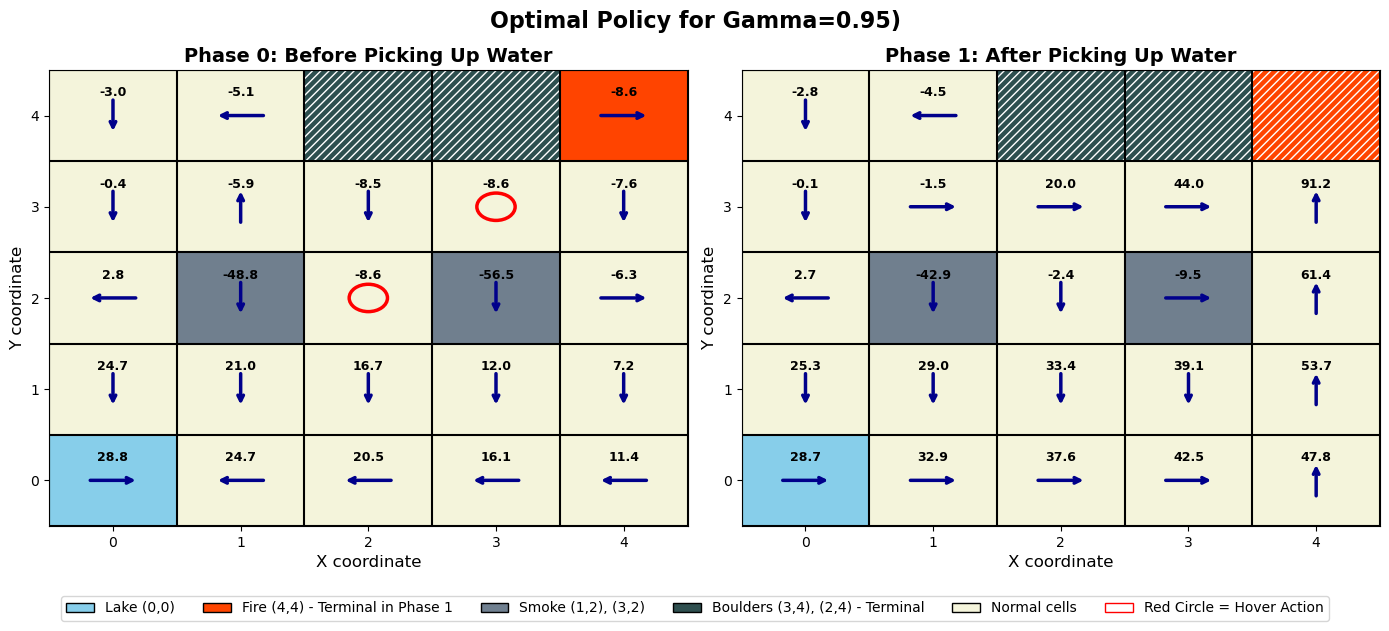

In [45]:
gridWorld_alt_Gamma=policy_iteration(0.95, 0.01,smoke_penalty=-90)
visualize_mdp(gridWorld_alt_Gamma, gamma=0.95,smoke_penalty=-90)